In [ ]:
# ---------------------------------
# 1: IMPORT REQUIRED LIBRARIES
# ---------------------------------
# Import libraries for data manipulation
import pandas as pd
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots within the notebook
%matplotlib inline

# Ignore warning messages for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ------------------------
#  2: LOAD THE DATASET
# ------------------------

# Load the loan default dataset into a pandas DataFrame
df = pd.read_csv('/content/Loan_default.csv')

# Display the first five records
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [ ]:
# ---------------------
#  3: DataSet Overview
# ---------------------

print(f"Rows   :{df.shape[0]}")
print(f"Columns:{df.shape[1]}")

Rows   :32345
Columns:18


In [ ]:
# Display the columns names
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [ ]:
# Display Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32345 entries, 0 to 32344
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   LoanID          32345 non-null  object 
 1   Age             32345 non-null  int64  
 2   Income          32345 non-null  int64  
 3   LoanAmount      32345 non-null  int64  
 4   CreditScore     32345 non-null  int64  
 5   MonthsEmployed  32345 non-null  int64  
 6   NumCreditLines  32345 non-null  int64  
 7   InterestRate    32345 non-null  float64
 8   LoanTerm        32345 non-null  int64  
 9   DTIRatio        32345 non-null  float64
 10  Education       32344 non-null  object 
 11  EmploymentType  32344 non-null  object 
 12  MaritalStatus   32344 non-null  object 
 13  HasMortgage     32344 non-null  object 
 14  HasDependents   32344 non-null  object 
 15  LoanPurpose     32344 non-null  object 
 16  HasCoSigner     32344 non-null  object 
 17  Default         32344 non-null 

In [ ]:
# Generate Summary Statistcis
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32345.000000,32344.000000
mean,43.502087,82524.614500,127619.996383,574.916432,59.552759,2.497759,13.479392,35.999629,0.503321,0.116281
std,14.998852,38999.036987,70945.278489,158.935469,34.549617,1.119666,6.628538,16.912617,0.230477,0.320567
min,18.000000,15000.000000,5005.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.000000,0.000000
25%,31.000000,48672.000000,66235.000000,437.000000,30.000000,1.000000,7.750000,24.000000,0.310000,0.000000
50%,43.000000,82582.000000,127703.000000,575.000000,60.000000,2.000000,13.490000,36.000000,0.510000,0.000000
75%,56.000000,116020.000000,189265.000000,713.000000,89.000000,4.000000,19.200000,48.000000,0.700000,0.000000
max,69.000000,149997.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [ ]:
# Check For Missing Values
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [ ]:
# Check For Duplicate Records
df.duplicated().sum()

np.int64(0)

# 4. Data Quality Assessment

The dataset was examined to identify potential data quality issues before analysis. The following checks were performed:

- No missing values were found in any of the features.
- No duplicate records were identified.
- All columns have appropriate data types.
- The dataset is clean and suitable for exploratory data analysis and machine learning.

In [ ]:
# Display the count of each class
df['Default'].value_counts()

,count
Default,
0.0,28583
1.0,3761


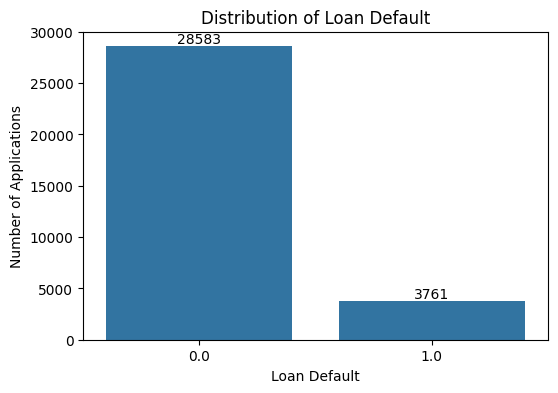

In [ ]:
# ---------------------------------
# 5. Exploratory Data Analysis(EDA)
# ---------------------------------

#Visualize the distribution of the target variable
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Default', data=df)

# Add count labels on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Loan Default")
plt.xlabel("Loan Default")
plt.ylabel("Number of Applications")

plt.show()

In [ ]:
# Display the count of each class
df['Default'].value_counts()

,count
Default,
0.0,28583
1.0,3761


In [ ]:
# Display the percentage distribution of each class
(df['Default'].value_counts(normalize=True) * 100).round(2)

,proportion
Default,
0.0,88.37
1.0,11.63


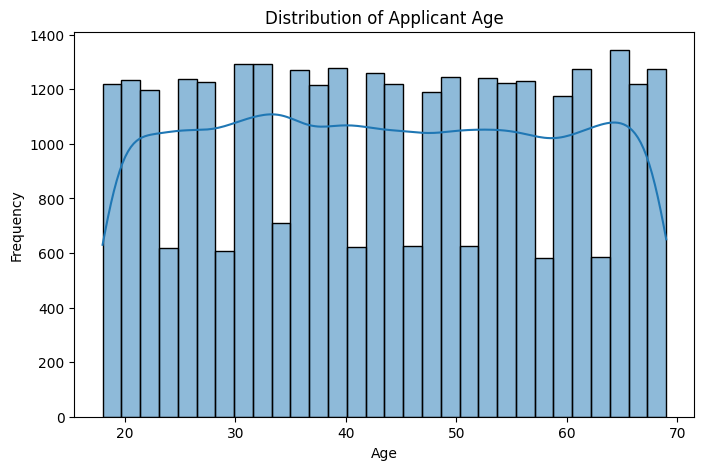

In [ ]:
# -----------------------------
# Distribution of Applicant Age
# ------------------------------

# Visualize the distribution of applicant age
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],bins=30,kde=True)
plt.title('Distribution of Applicant Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [ ]:
df['Age'].describe()

,Age
count,32345.000000
mean,43.502087
std,14.998852
min,18.000000
25%,31.000000
50%,43.000000
75%,56.000000
max,69.000000


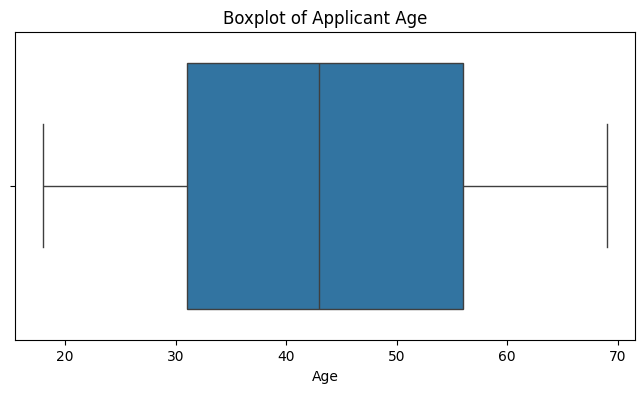

In [ ]:
# --------------------------
# Age Distribution (Boxplot)
# --------------------------

# Visualize the spread of applicant age

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Age'])

plt.title("Boxplot of Applicant Age")
plt.xlabel("Age")

plt.show()

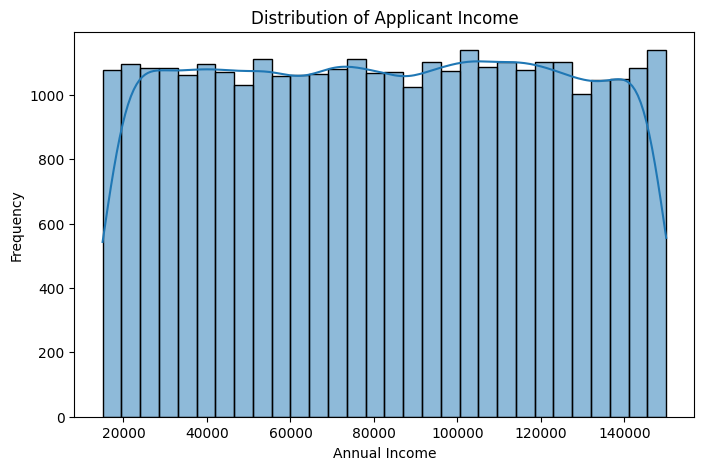

In [ ]:
# --------------------------------
# Distribution of Applicant Income
# --------------------------------

# Visualize the distribution of applicant income

plt.figure(figsize=(8,5))

sns.histplot(df['Income'], bins=30, kde=True)

plt.title("Distribution of Applicant Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

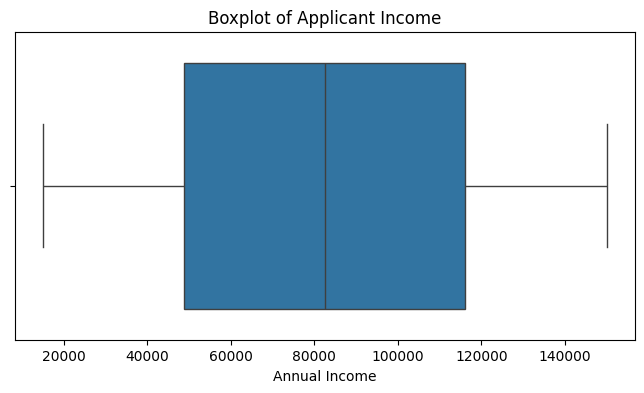

In [ ]:
# ----------------------------
# Boxplot of Applicant Income
# ----------------------------

# Visualize the spread of applicant income

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Income'])

plt.title("Boxplot of Applicant Income")
plt.xlabel("Annual Income")

plt.show()

In [ ]:
# Display summary statistics for applicant income
df['Income'].describe()

,Income
count,32345.000000
mean,82524.614500
std,38999.036987
min,15000.000000
25%,48672.000000
50%,82582.000000
75%,116020.000000
max,149997.000000


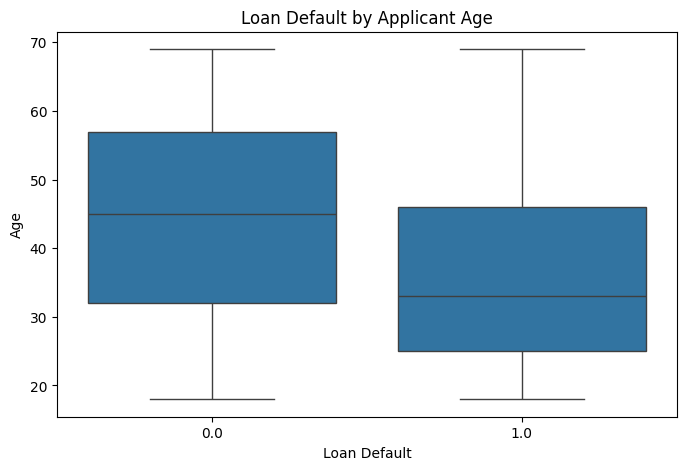

In [ ]:
# --------------------
# Loan Default by Age
# --------------------

# Compare applicant age across loan default categories

plt.figure(figsize=(8,5))

sns.boxplot(x='Default', y='Age', data=df)

plt.title("Loan Default by Applicant Age")
plt.xlabel("Loan Default")
plt.ylabel("Age")

plt.show()

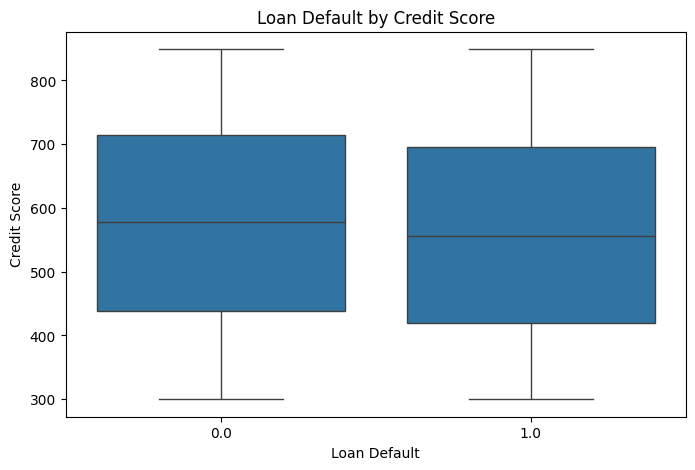

In [ ]:
# ----------------------------
# Loan Default by Credit Score
# ----------------------------

# Compare credit scores across loan default categories

plt.figure(figsize=(8,5))

sns.boxplot(x='Default', y='CreditScore', data=df)

plt.title("Loan Default by Credit Score")
plt.xlabel("Loan Default")
plt.ylabel("Credit Score")

plt.show()

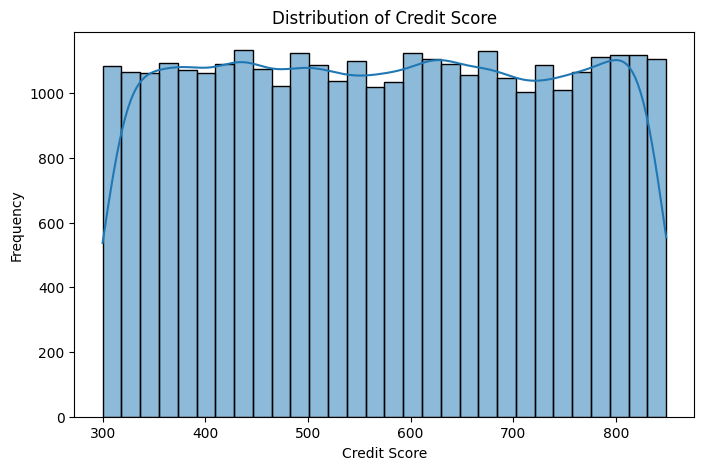

In [ ]:
# ----------------------------
# Distribution of Credit Score
# ----------------------------

# Visualize the distribution of credit scores

plt.figure(figsize=(8,5))

sns.histplot(df['CreditScore'], bins=30, kde=True)

plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Display summary statistics for credit score
df['CreditScore'].describe()

,CreditScore
count,32345.000000
mean,574.916432
std,158.935469
min,300.000000
25%,437.000000
50%,575.000000
75%,713.000000
max,849.000000


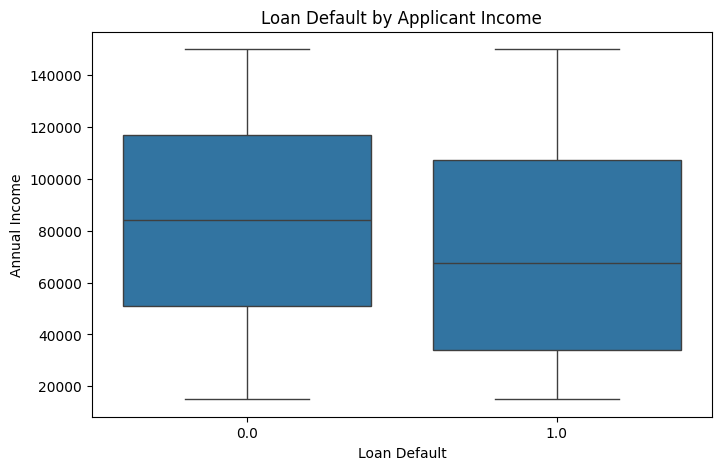

In [ ]:
# --------------------------------
# Loan Default by Applicant Income
# --------------------------------

# Compare applicant income across loan default categories

plt.figure(figsize=(8,5))

sns.boxplot(x='Default', y='Income', data=df)

plt.title("Loan Default by Applicant Income")
plt.xlabel("Loan Default")
plt.ylabel("Annual Income")

plt.show()

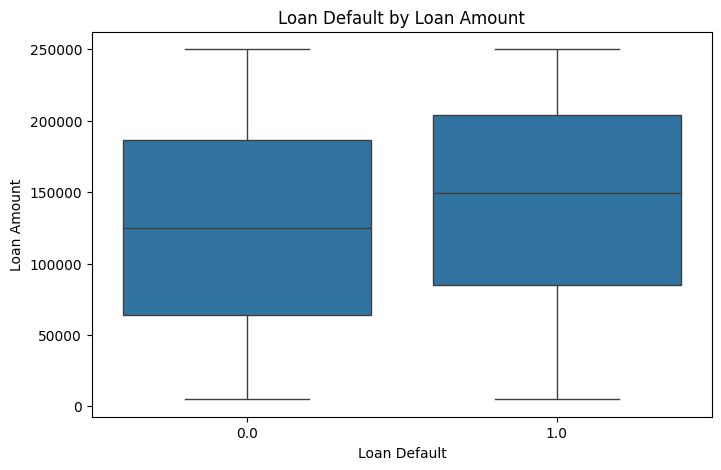

In [ ]:
# ----------------------------
# Loan Default by Loan Amount
# ----------------------------

# Compare loan amount across loan default categories

plt.figure(figsize=(8,5))

sns.boxplot(x='Default', y='LoanAmount', data=df)

plt.title("Loan Default by Loan Amount")
plt.xlabel("Loan Default")
plt.ylabel("Loan Amount")

plt.show()

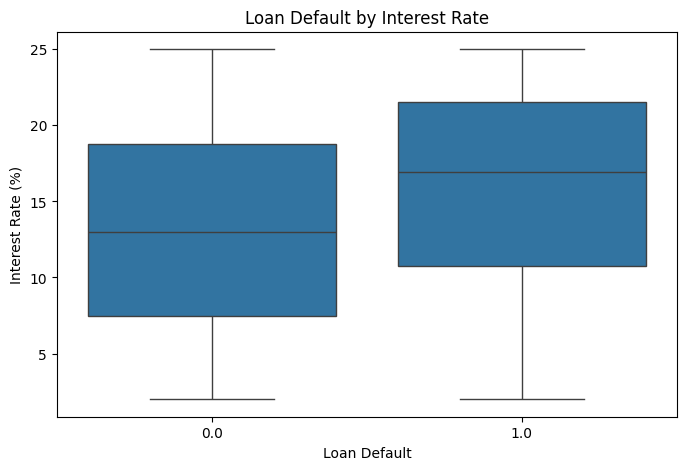

In [ ]:
# ----------------------------
# Loan Default by Interest Rate
# ----------------------------

# Compare interest rate across loan default categories

plt.figure(figsize=(8,5))

sns.boxplot(x='Default', y='InterestRate', data=df)

plt.title("Loan Default by Interest Rate")
plt.xlabel("Loan Default")
plt.ylabel("Interest Rate (%)")

plt.show()

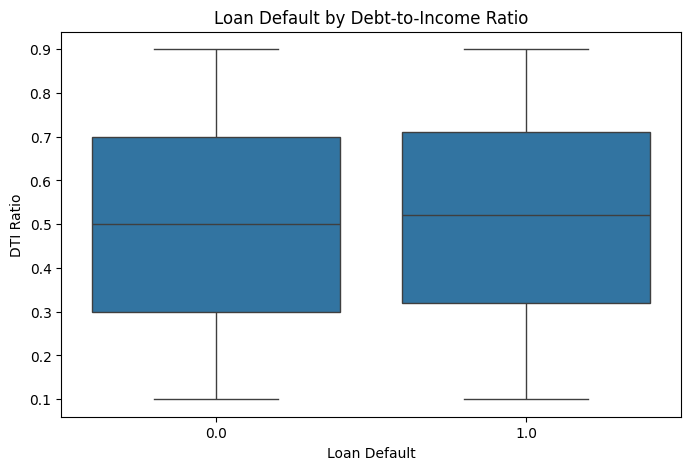

In [ ]:
# ------------------------------------
# Loan Default by Debt-to-Income Ratio
# ------------------------------------

# Compare DTI ratio across loan default categories

plt.figure(figsize=(8,5))

sns.boxplot(x='Default', y='DTIRatio', data=df)

plt.title("Loan Default by Debt-to-Income Ratio")
plt.xlabel("Loan Default")
plt.ylabel("DTI Ratio")

plt.show()

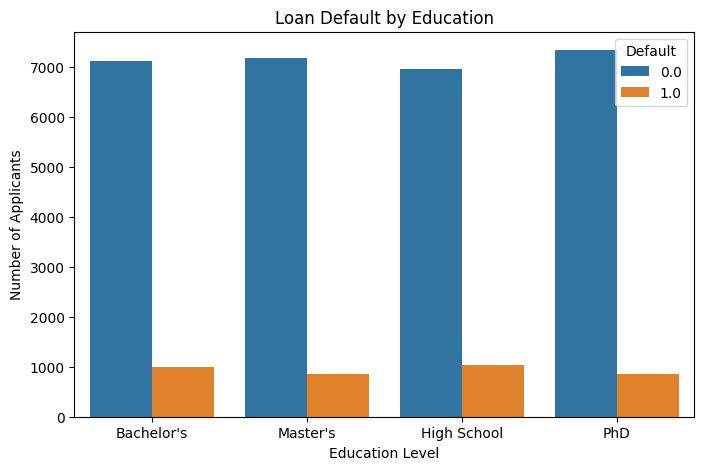

In [ ]:
# --------------------------
# Loan Default by Education
# --------------------------

# Compare loan default across different education levels

plt.figure(figsize=(8,5))

sns.countplot(x='Education', hue='Default', data=df)

plt.title("Loan Default by Education")
plt.xlabel("Education Level")
plt.ylabel("Number of Applicants")

plt.legend(title="Default")

plt.show()

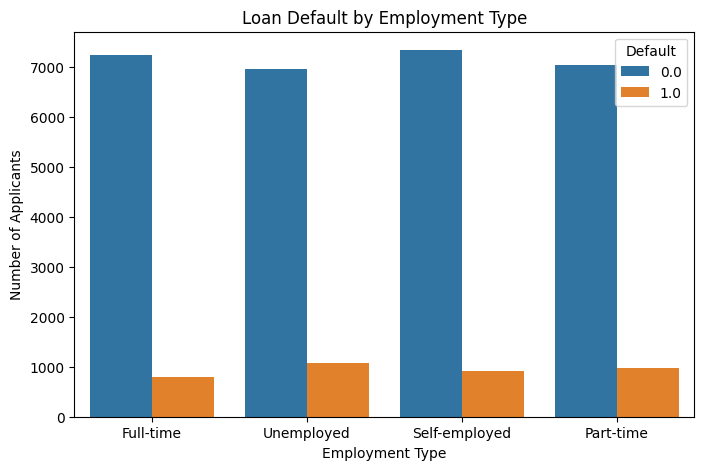

In [ ]:
# --------------------------------
# Loan Default by Employment Type
# --------------------------------

# Compare loan default across employment types

plt.figure(figsize=(8,5))

sns.countplot(x='EmploymentType', hue='Default', data=df)

plt.title("Loan Default by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Applicants")

plt.legend(title="Default")

plt.show()

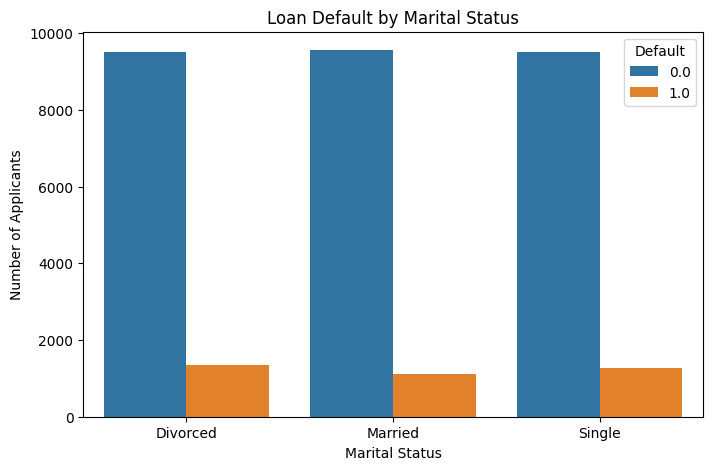

In [ ]:
# -------------------------------
# Loan Default by Marital Status
# -------------------------------

# Compare loan default across marital status

plt.figure(figsize=(8,5))

sns.countplot(x='MaritalStatus', hue='Default', data=df)

plt.title("Loan Default by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Applicants")

plt.legend(title="Default")

plt.show()

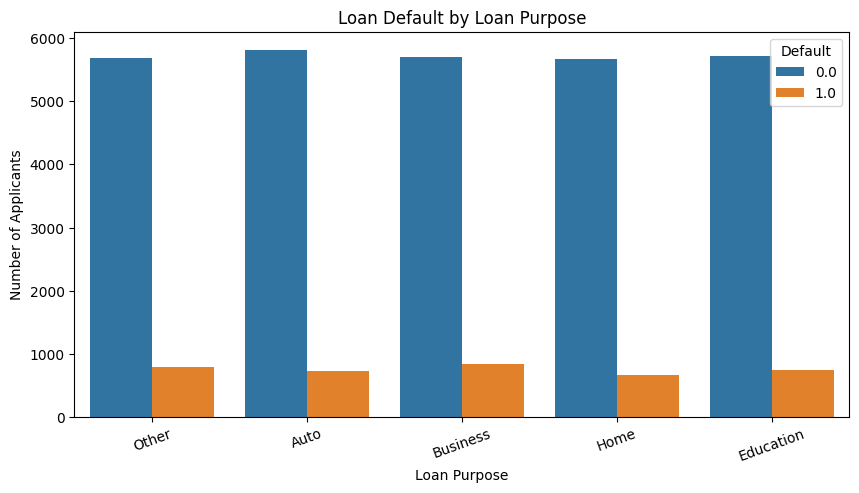

In [ ]:
# -----------------------------
# Loan Default by Loan Purpose
# -----------------------------

# Compare loan default across different loan purposes

plt.figure(figsize=(10,5))

sns.countplot(x='LoanPurpose', hue='Default', data=df)

plt.title("Loan Default by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=20)

plt.legend(title="Default")

plt.show()

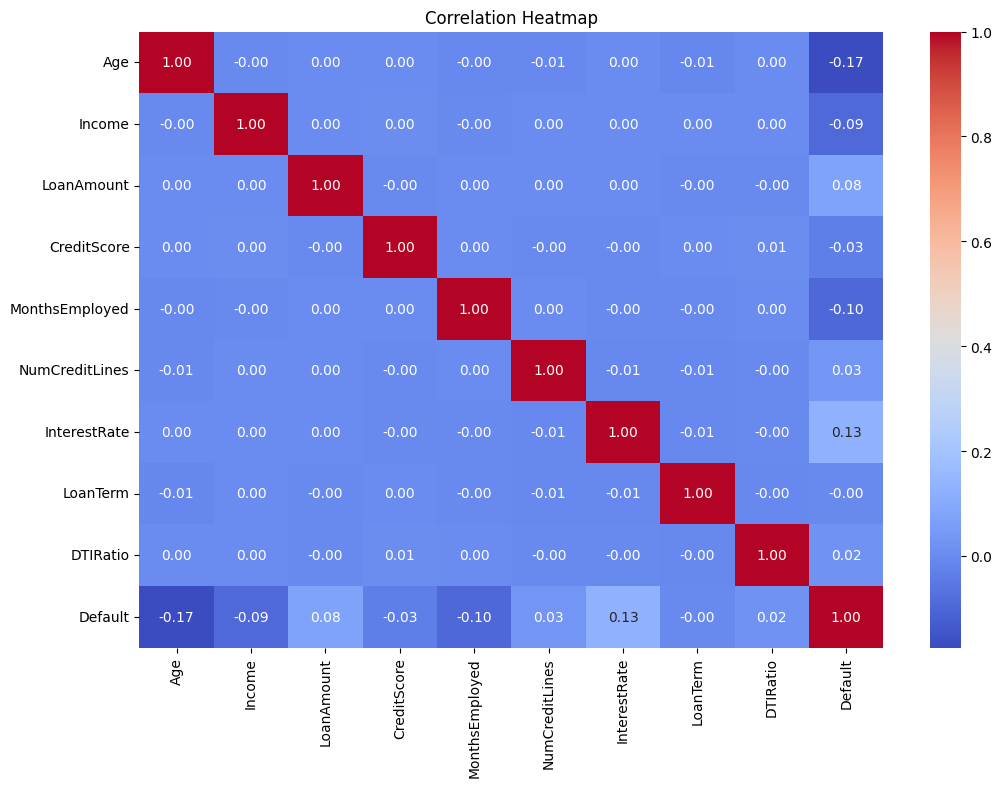

In [ ]:
# -------------------
# Correlation Heatmap
# -------------------

# Compute the correlation matrix for numerical features
correlation_matrix = df.corr(numeric_only=True)

# Plot the correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Display the correlation of all numerical features with the target variable
correlation_matrix['Default'].sort_values(ascending=False)

,Default
Default,1.000000
InterestRate,0.131633
LoanAmount,0.075760
NumCreditLines,0.033863
DTIRatio,0.019741
LoanTerm,-0.002182
CreditScore,-0.032766
Income,-0.094291
MonthsEmployed,-0.097141
Age,-0.174117


In [ ]:
# ----------------------
# 6. Data Preprocessing
# ----------------------

# ------------------------
# Remove Identifier Column
# ------------------------

# Remove the LoanID column
df = df.drop('LoanID', axis=1)

# Display the first five records
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [ ]:
# --------------------------------------
# Separate Features and Target Variable
# --------------------------------------

# Create the feature matrix
X = df.drop('Default', axis=1)

# Create the target variable
y = df['Default']

# Display the dimensions
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (32345, 16)
Target Shape   : (32345,)


In [ ]:
# ----------------------------
# Encode Categorical Features
# ----------------------------
# Convert categorical features into numerical features
X = pd.get_dummies(X, drop_first=True)

# Display the first five records
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education_High School,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,False,...,False,False,False,True,True,False,False,False,True,True
1,69,50432,124440,458,15,1,4.81,60,0.68,False,...,False,True,False,False,False,False,False,False,True,True
2,46,84208,129188,451,26,3,21.17,24,0.31,False,...,True,False,False,True,True,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,True,...,False,True,False,False,False,True,False,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,False,...,True,False,False,False,True,False,False,False,False,False


In [ ]:
X.shape

(32345, 24)

In [ ]:
# -------------------------------
# 7.Import Train-Test Split Library
# -------------------------------

from sklearn.model_selection import train_test_split

# -------------------------------------------------
# Split the Dataset into Training and Testing Sets
# -------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the dimensions of the split datasets
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (25876, 24)
Testing Features  : (6469, 24)
Training Target   : (25876,)
Testing Target    : (6469,)


In [ ]:
# ------------------------
# 8.Import StandardScaler
# ------------------------

from sklearn.preprocessing import StandardScaler

# ------------------------------
# Standardize Numerical Features
# ------------------------------

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both datasets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Check for missing values in the target variable
y.isnull().sum()

np.int64(1)

In [ ]:
# Display unique values in the target variable
y.unique()

array([ 0.,  1., nan])

In [ ]:
# Display the row where the target variable is missing
df[df['Default'].isnull()]

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
32344,56,110630,107564,497,81,4,20.17,36,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Count missing values in the target column
df['Default'].isnull().sum()

np.int64(1)

In [ ]:
# Remove rows with missing target values
df = df.dropna(subset=['Default'])

In [ ]:
# Separate features and target variable again
X = df.drop('Default', axis=1)
y = df['Default']

In [ ]:
y.isnull().sum()

np.int64(0)

In [ ]:
df[df['Default'].isnull()]

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default


In [ ]:
# Check missing values in training target
y_train.isnull().sum()

np.int64(1)

In [ ]:
# Check missing values in testing target
y_test.isnull().sum()

np.int64(0)

In [ ]:
# Check missing values in the full target
y.isnull().sum()

np.int64(0)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(25876, 24)
(25876,)


In [ ]:
# Create feature matrix and target variable
X = df.drop('Default', axis=1)
y = df['Default']

In [ ]:
# Convert categorical features into numerical features
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print(y_train.isnull().sum())
print(y_test.isnull().sum())

0
0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# ----------------------
# 9.Predict Loan Default
# ----------------------

# Predict the class labels
y_pred_lr = log_reg.predict(X_test)

# Predict the probability of loan default
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

In [ ]:
# -------------------------
# Import Evaluation Metrics
# -------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [ ]:
# --------------------------------
# Logistic Regression Performance
# --------------------------------

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8817
Precision: 0.7179
Recall   : 0.0358
F1 Score : 0.0682
ROC-AUC  : 0.7465


In [ ]:
# ---------------------
# Classification Report
# ---------------------

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94      5687
         1.0       0.72      0.04      0.07       782

    accuracy                           0.88      6469
   macro avg       0.80      0.52      0.50      6469
weighted avg       0.86      0.88      0.83      6469



<Figure size 600x500 with 0 Axes>

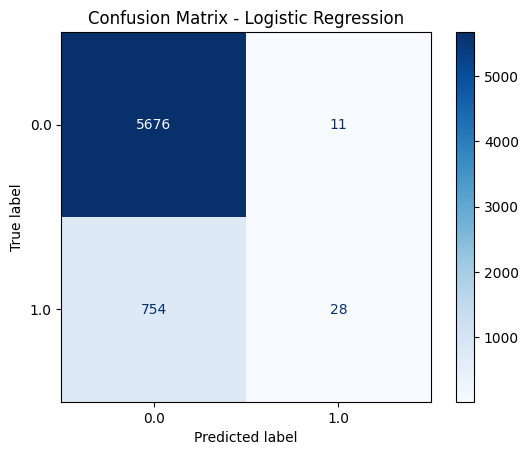

In [ ]:
# ----------------
# Confusion Matrix
# ----------------

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

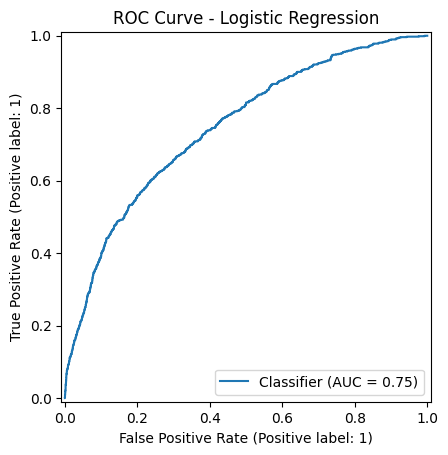

In [ ]:
# ---------
# ROC Curve
# ---------

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [ ]:
# -------------------------------
# 10.Import Decision Tree Classifier
# -------------------------------

from sklearn.tree import DecisionTreeClassifier

In [ ]:
# -----------------------------
# Train the Decision Tree Model
# -----------------------------

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# -----------------------------
# Predict using Decision Tree
# -----------------------------

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [ ]:
# -----------------------------
# Decision Tree Performance
# -----------------------------

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")

Accuracy : 0.7967
Precision: 0.1926
Recall   : 0.2136
F1 Score : 0.2025
ROC-AUC  : 0.5452


In [ ]:
# ---------------------
# Classification Report
# ---------------------

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       0.89      0.88      0.88      5687
         1.0       0.19      0.21      0.20       782

    accuracy                           0.80      6469
   macro avg       0.54      0.55      0.54      6469
weighted avg       0.81      0.80      0.80      6469



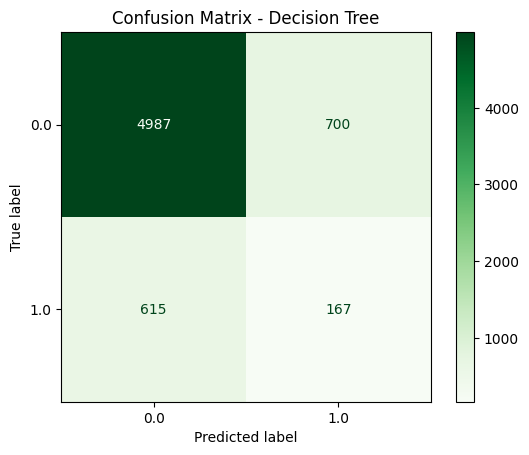

In [ ]:
# -----------------
# Confusion Matrix
# -----------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap="Greens"
)

plt.title("Confusion Matrix - Decision Tree")
plt.show()

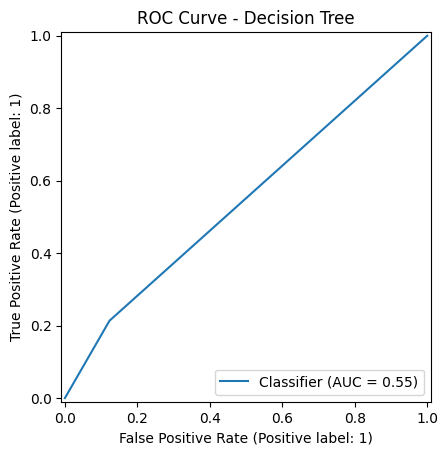

In [ ]:
# ---------
# ROC Curve
# ---------

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_dt
)

plt.title("ROC Curve - Decision Tree")
plt.show()

In [ ]:
# -------------------------------
# 11.Import Random Forest Classifier
# -------------------------------

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# -------------------------------
# Train the Random Forest Model
# -------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# -------------------------------
# Predict using Random Forest
# -------------------------------

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [ ]:
# -------------------------------
# Random Forest Performance
# -------------------------------

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.8804
Precision: 0.7222
Recall   : 0.0166
F1 Score : 0.0325
ROC-AUC  : 0.7173


In [ ]:
# ---------------------
# Classification Report
# ---------------------

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94      5687
         1.0       0.72      0.02      0.03       782

    accuracy                           0.88      6469
   macro avg       0.80      0.51      0.48      6469
weighted avg       0.86      0.88      0.83      6469



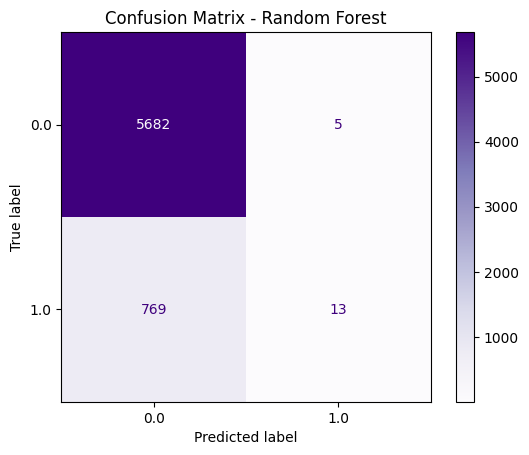

In [ ]:
# ----------------
# Confusion Matrix
# -----------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Purples"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

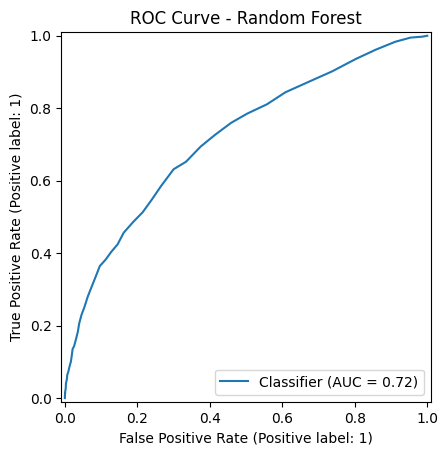

In [ ]:
# ---------
# ROC Curve
# ---------

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("ROC Curve - Random Forest")
plt.show()

In [ ]:
# ----------------
# 12.Model Comparison
# ----------------

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_rf
    ],
    "F1 Score": [
        f1,
        f1_dt,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.881744,0.717949,0.035806,0.068210,0.746495
1,Decision Tree,0.796723,0.192618,0.213555,0.202547,0.545234
2,Random Forest,0.880352,0.722222,0.016624,0.032500,0.717294


In [ ]:
comparison.style.highlight_max(
    subset=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"],
    color="pink"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.881744,0.717949,0.035806,0.068210,0.746495
1,Decision Tree,0.796723,0.192618,0.213555,0.202547,0.545234
2,Random Forest,0.880352,0.722222,0.016624,0.032500,0.717294


In [ ]:
# -------------------
# 13.Feature Importance
# -------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Income,0.120416
6,InterestRate,0.118451
2,LoanAmount,0.108144
0,Age,0.105277
4,MonthsEmployed,0.098215
3,CreditScore,0.096179
8,DTIRatio,0.087438
7,LoanTerm,0.039705
5,NumCreditLines,0.032734
17,HasMortgage_Yes,0.016365


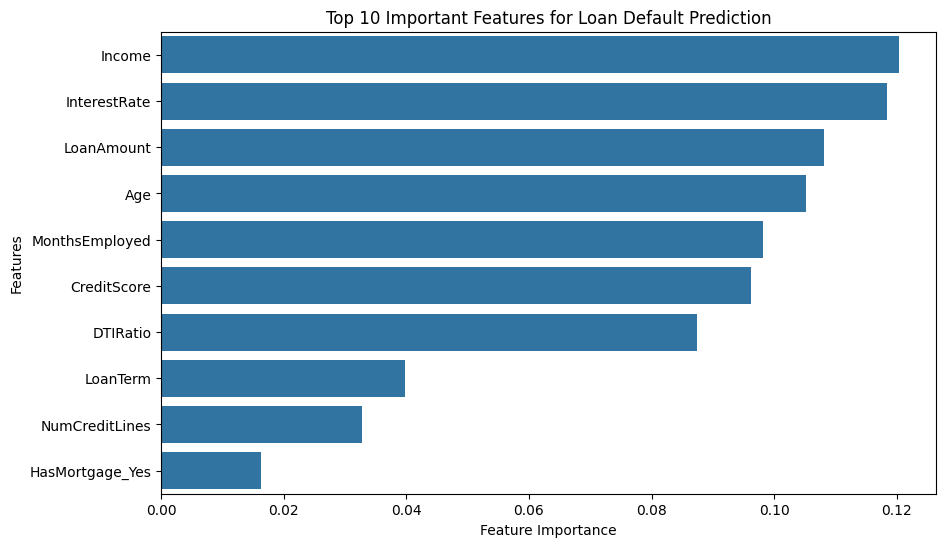

In [ ]:
# -------------------------
# Top 10 Important Features
# -------------------------

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features for Loan Default Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.show()

In [ ]:
# ==========================================
# Predict Loan Default for a New Applicant
# ==========================================

new_customer = pd.DataFrame({
    'Age': [35],
    'Income': [70000],
    'LoanAmount': [25000],
    'CreditScore': [720],
    'MonthsEmployed': [60],
    'NumCreditLines': [3],
    'InterestRate': [8.5],
    'LoanTerm': [36],
    'DTIRatio': [0.25],
    'Education': ['Bachelor'],
    'EmploymentType': ['Full-time'],
    'MaritalStatus': ['Married'],
    'HasMortgage': ['Yes'],
    'HasDependents': ['No'],
    'LoanPurpose': ['Home'],
    'HasCoSigner': ['Yes']
})

In [ ]:
# Convert categorical variables to dummy variables
new_customer = pd.get_dummies(new_customer)

# Match the training dataset columns
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

In [ ]:
# Scale the applicant's features
new_customer_scaled = scaler.transform(new_customer)

In [ ]:
# Predict loan default
prediction = rf_model.predict(new_customer_scaled)

# Predict probability
probability = rf_model.predict_proba(new_customer_scaled)

In [ ]:
print("-" * 45)
print("      LOAN DEFAULT PREDICTION")
print("-" * 45)

if prediction[0] == 1:
    print("Prediction            : Default")
else:
    print("Prediction            : No Default")

print(f"Probability of Default: {probability[0][1]*100:.2f}%")
print(f"Probability of Repayment: {probability[0][0]*100:.2f}%")

print("-" * 45)

---------------------------------------------
      LOAN DEFAULT PREDICTION
---------------------------------------------
Prediction            : No Default
Probability of Default: 1.00%
Probability of Repayment: 99.00%
---------------------------------------------


In [ ]:
import joblib

joblib.dump(rf_model, "loan_default_prediction_model.pkl")

['loan_default_prediction_model.pkl']